In [ ]:
import torch as tr
from torch import nn
device =  "cuda" if tr.cuda.is_available() else "cpu"
device


'cuda'

## We are using food101 dataset here for custom dataset model creation

In [9]:
import requests 
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} direcrtory already exists")
else:
    print(f"{image_path} directory does not exist, creating a new one")
    image_path.mkdir(parents = True, exist_ok = True)


data\pizza_steak_sushi directory does not exist, creating a new one


In [12]:
with open(data_path / "pizza_steak_sushi.zip" , "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/baa27b691617461c173ecf3439793cd8cde74e13/data/pizza_steak_sushi.zip")
    print("Downloading pizza_steak_sushi.zip")

In [14]:
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Extracting pizza_steak_sushi.zip")
    zip_ref.extractall(image_path)

Extracting pizza_steak_sushi.zip


In [15]:
import os 
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [16]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

data\pizza_steak_sushi\test\pizza\2871261.jpg
pizza
384
512


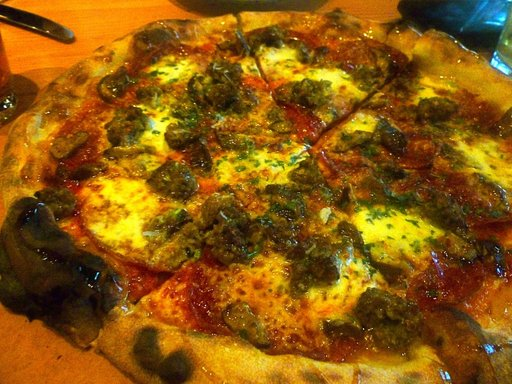

In [ ]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.name
print(image_class)
img = Image.open(random_image_path)

print(img.height)
print(img.width)
img

(384, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

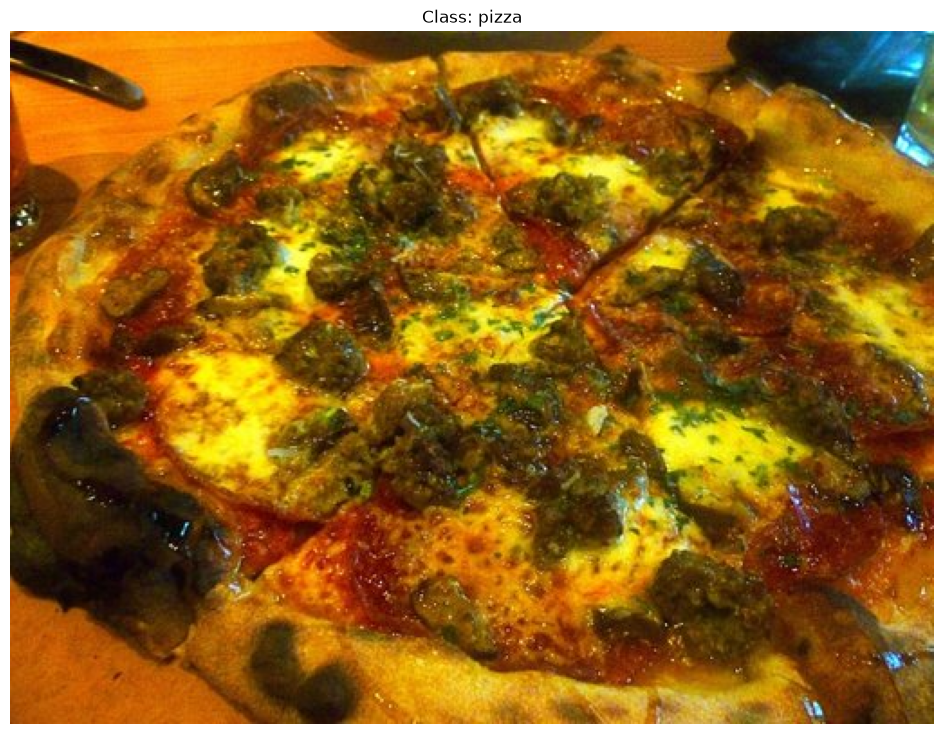

In [100]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array = np.array(img)
plt.figure(figsize = (150, 9))
plt.imshow(img_as_array)
print(img_as_array.shape)
plt.title(f"Class: {image_class}")
plt.axis(False)

In [103]:
img_as_array[1]

array([[164,  98,  14],
       [154,  86,   3],
       [140,  67,   0],
       ...,
       [ 59, 158, 177],
       [ 69, 166, 175],
       [ 65, 160, 164]], shape=(512, 3), dtype=uint8)

In [105]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [117]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()
])

In [118]:
data_transform(img).shape

torch.Size([3, 64, 64])

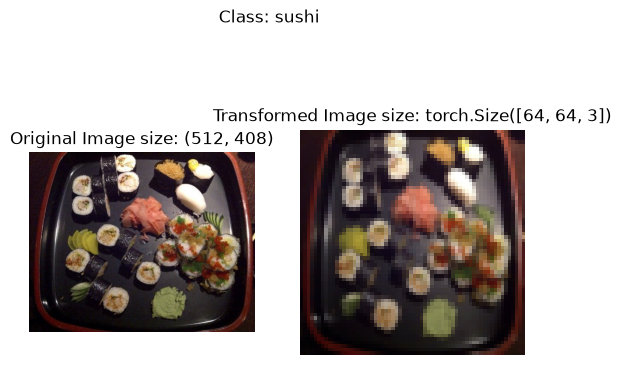

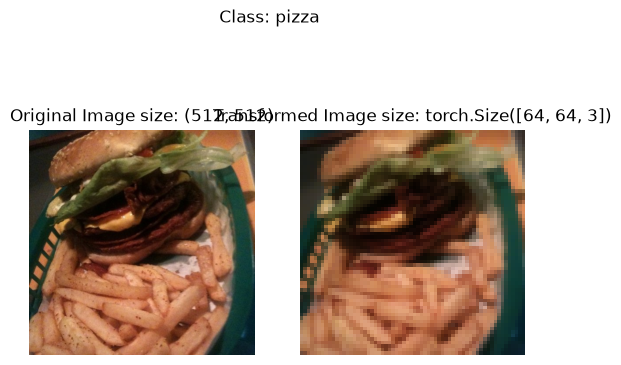

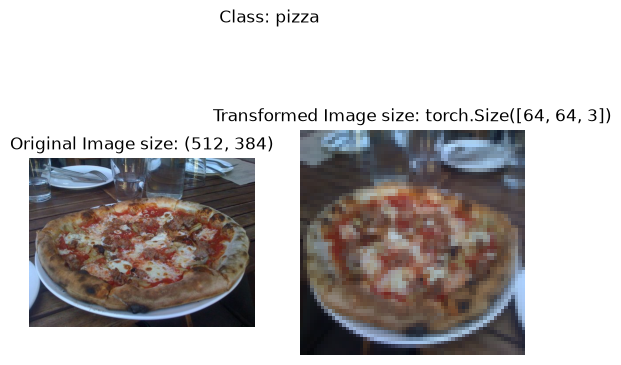

In [119]:
def plot_transformed_image(image_path, transform, n = 3, seed = 42):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_path, k = n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax= plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original Image size: {f.size}")
            ax[0].axis(False)
            transformed_image = transform(f).permute(1, 2, 0)

            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Image size: {transformed_image.size()}")
            ax[1].axis("off")
            fig.suptitle(f"Class: {image_path.parent.name}")

plot_transformed_image(image_path_list, data_transform, n = 3, seed = 42)

In [122]:
train_data = datasets.ImageFolder(root = train_dir, transform = data_transform, target_transform = None)
test_data = datasets.ImageFolder(root = test_dir, transform = data_transform, target_transform = None)
print(train_data, test_data)

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data\pizza_steak_sushi\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ) Dataset ImageFolder
    Number of datapoints: 75
    Root location: data\pizza_steak_sushi\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [124]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [126]:
class_dict = train_data.class_to_idx
class_dict


{'pizza': 0, 'steak': 1, 'sushi': 2}

In [133]:
train_data[1]
img, label = train_data[0][0], train_data[0][1]

img, label, img.shape, img.dtype,type(label), label

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

torch.Size([64, 64, 3]) torch.float32 <class 'int'> 0


Text(0.5, 1.0, '0')

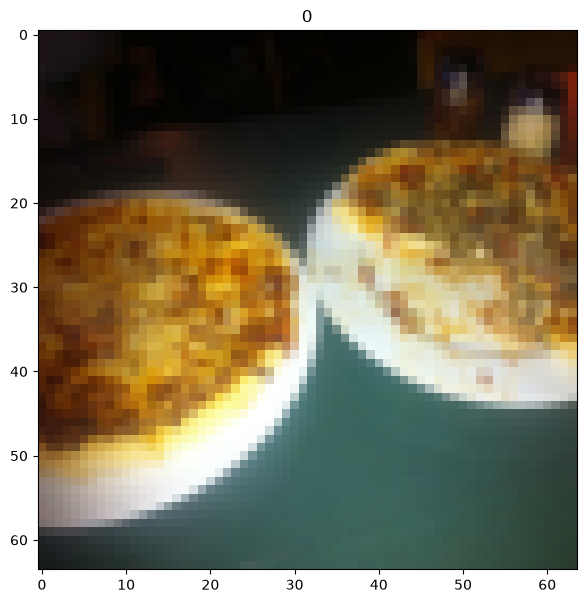

In [138]:
img_permute = img.permute(1, 2, 0)
print(img_permute.shape, img_permute.dtype, type(label), label)
plt.figure(figsize = (10, 7))
plt.imshow(img_permute)
plt.title(label)


In [148]:
# turn loaded images into dataloader
Batch_size = 32
train_dataloader = DataLoader(dataset = train_data, batch_size = Batch_size, num_workers = 1,  shuffle = True)
test_dataloader = DataLoader(dataset= test_data, batch_size = Batch_size, num_workers = 1, shuffle = False)


In [149]:
len(train_dataloader), len(test_dataloader), len(train_data)

(8, 3, 225)

In [150]:
image, label = next(iter(train_dataloader))
print(f"Image batch shape: {image.size()} \nLabel batch shape: {label.size()}")

Image batch shape: torch.Size([32, 3, 64, 64]) 
Label batch shape: torch.Size([32])


In [157]:
from typing import List, Dict, Tuple

In [153]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [155]:
## set the target directory 

target_directory = train_dir
print(f"Target Directory: {target_directory}")

Target Directory: data\pizza_steak_sushi\train


In [156]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [161]:
def find_class(directory)-> Tuple[List[str], Dict[str, int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    if not classes:
        raise FileNotFoundError(f"No class directories found in {directory}.")
    return classes, class_to_idx

In [164]:
# find_class(target_directory)
find_class(test_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})